# Distribuciones continuas de masa

[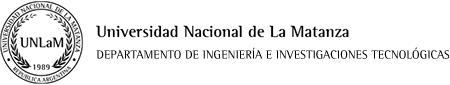](https://ingenieria.unlam.edu.ar/)  
[by-nc-sa_80x15.png](https://creativecommons.org/licenses/by-sa/4.0/deed.es_ES) 
2024 [Víctor A. Bettachini](mailto:vbettachini@unlam.edu.ar)  

---

> ## 🎯 Objetivos
>
> Al completar esta clase, el estudiante podrá:
>
> 1. **Generalizar el tensor de inercia** pasando de sumatorias sobre masas puntuales a integrales volumétricas para distribuciones continuas.
> 2. **Implementar el cálculo de densidad** ($\rho$) a partir de la masa y el volumen obtenido mediante integración simbólica en SymPy.
> 3. **Utilizar Jacobianos** de transformación para operar correctamente en sistemas de coordenadas cilíndricas y esféricas.
> 4. **Calcular momentos de inercia** de sólidos fundamentales (cilindros, varillas y casquetes esféricos) de manera analítica.
> 5. **Aplicar el Teorema de Steiner** para determinar la inercia de cuerpos que rotan fuera de su centro de masa, facilitando el modelado de sistemas mecánicos reales.
>
---
> ## 📚 Prerrequisitos
>
> Para aprovechar este cuaderno se asume que el estudiante conoce:
>
> #### Matemática
> - **Cálculo integral**: resolución de integrales múltiples (dobles y triples).
> - **Sistemas de coordenadas**: familiaridad con coordenadas polares, cilíndricas y esféricas, incluyendo sus vectores base.
> - **Geometría**: conceptos de volumen y área de cuerpos sólidos comunes.
>
> #### Física
> - **Tensor de inercia**: haber completado la lección teórica introductoria sobre el tensor de inercia para masas puntuales.
> - **Mecánica del Sólido Rígido**: nociones de centro de masa y teorema de los ejes paralelos.
>
> #### Programación / Herramientas
> - **SymPy Avanzado**: uso de la función `sm.Integral` y el método `.doit()` para resolver integrales simbólicamente.
> - **Manejo de constantes**: definición de símbolos con restricciones (e.g., `positive=True`) para simplificar resultados algebraicos.
---

## Tensor de inercia para masas puntales

Con el tensor de 2.o orden $I_{ik}$ se calcula $T = \frac{m}{2} \dot{\vec{R}}^2 + \frac{1}{2} I_{ik} \Omega_i \Omega_k$

$$
\overline{\overline{I}}
= I_{ik} = 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
=
\begin{pmatrix}
\sum_p m_p (y_p^2 + z_p^2) & - \sum_p m_p x_p y_p & - \sum_p m_p x_p z_p \\
- \sum_p m_p y_p x_p & \sum_p m_p (x_p^2 + z_p^2)  & - \sum_p m_p y_p z_p \\
- \sum_p m_p z_p x_p & - \sum_p m_p z_p y_p & \sum_p m_p (x_p^2 + y_p^2) \\
\end{pmatrix}
$$
- El tensor $\overline{\overline{I}}$ es simétrico
- $I_{xx}, I_{yy}, I_{zz}$: **momentos de inercia**, los otros **productos de inercia**

## Tensor de inercia para distribuciones continuas de masa

En el tensor de inercia $I_{ik}$ la sumatoria sobre posiciones discretas de masas se reemplaza por una integración continua en todo el volumen de la densidad en función de la posición $\tilde{\rho}(\vec{r})$

$$
I_{ik} = \iiint \tilde{\rho}(\vec{r}) \left[ x_l^2 \delta_{ik} -  x_i x_k \right] dV.
$$

$$
\overline{\overline{I}}
= I_{ik} = 
\begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz} \\
\end{pmatrix}
=
\begin{pmatrix}
\iiint \tilde{\rho}(\vec{r}) (y^2 + z^2) dV  &  - \iiint \tilde{\rho}(\vec{r}) x y dV  &  - \iiint \tilde{\rho}(\vec{r}) x z dV \\
- \iiint \tilde{\rho}(\vec{r}) y x dV  &  \iiint \tilde{\rho}(\vec{r}) (x^2 + z^2) dV  &  - \iiint \tilde{\rho}(\vec{r}) y z dV \\
- \iiint \tilde{\rho}(\vec{r}) z x dV  &  - \iiint \tilde{\rho}(\vec{r}) z y dV  &   \iiint \tilde{\rho}(\vec{r}) (x^2 + y^2) dV \\
\end{pmatrix}
$$

## Momentos de inercia de sólidos simples

Cada vez que tenga que realizar un ejercicio no vuelva a inventar la rueda, use los resultados de aquí abajo o los de la 

>**Referencia**   
[Lista de tensiones de inercia en 3 dimensiones](https://es.wikipedia.org/wiki/Anexo:Momentos_de_inercia#Lista_de_tensores_de_inercia_en_3_dimensiones)  
Wikipedia  

### **Cilíndro homogéneo**   
![](figs/Moment_of_inertia_solid_cylinder.svg.png)

Es conveniente trabajar en coordenadas cilíndricas, por lo que $dV = \rho \, d\rho \, d\varphi \, dz$, ya que $\rho$ es el jacobiano para este sistema de coordenadas.

In [ ]:
import sympy as sm

In [ ]:
ro, z, fi = sm.symbols('rho z varphi') # variables sistema de coordenadas cilíndricas
r, h = sm.symbols('r h') # definimos los símbolos para la densidad, radio de la base y altura
cilíndricas_jacobiano = ro # jacobiano de la transformación cilíndricas a cartesianas

Si se cuenta con el dato de densidad de un objeto, se puede calcular el tensor de inercia de un objeto.
Pero es usual que no se tenga el dato de densidad, sino que se tenga el dato de masa producto de una pesada.
Resta entonces calcular la densidad a partir de la masa y el volumen.

In [ ]:
cilindro_volumen = sm.Eq(
  sm.Symbol('Volumen_{cilindro}'),
  sm.Integral(
    cilíndricas_jacobiano,
    (ro, 0, r), (fi, 0, 2 * sm.pi), (z, -h/2, h/2)
    )
)
cilindro_volumen

Eq(Volumen_{cilindro}, Integral(rho, (rho, 0, r), (varphi, 0, 2*pi), (z, -h/2, h/2)))

In [3]:
cilindro_volumen.doit()

Eq(Volumen_{cilindro}, pi*h*r**2)

Para evitar una confusión del radio de coordenadas cilíndricas $\rho$ con la densidad notaremos esta última $\tilde{\rho}$.

In [4]:
m = sm.Symbol('m') # definimos el símbolo para la masa
cilindro_densidad = sm.Eq(
  sm.Symbol(r'\tilde{\rho}_{cilindro}'),
  m/ cilindro_volumen.rhs.doit()
)
cilindro_densidad

Eq(\tilde{\rho}_{cilindro}, m/(pi*h*r**2))


Recordamos la expresión de los elementos del tensor de inercia para un sistema continuo

$$
I_{ik} = \iiint \tilde{\rho}(\vec{r}) \left[ x_l^2 \delta_{ik} -  x_i x_k \right] dV .
$$

Para calcular $I_{zz}$, el momento de inercia en la dirección de $\hat{z}$, se tiene que $i=z$ e $k=z$

$$
\begin{aligned}
I{zz} 
&= \iiint \tilde{\rho}(\vec{r}) \left[ x^2 + y^2 + z^2 - zz \right] dV \\
&= \iiint \tilde{\rho}(\vec{r}) \left[ x^2 + y^2 \right] dV \\
&= \iiint \tilde{\rho}(\vec{r}) \left[ \left(\rho^2 \cos^2{\varphi} \right) + \left(\rho^2 \sin^2{\varphi} \right) \right] dV \\
&= \iiint \tilde{\rho}(\vec{r}) \left[ \rho^2 \left( \cos^2{\varphi} + \sin^2{\varphi} \right) \right] dV \\
&= \iiint \tilde{\rho}(\vec{r}) \left[ \rho^2 \right] dV \\
\end{aligned}
$$

Queda claro entonces que para determinar $\left[ x_l^2 \delta_{ik} - x_i x_k \right]$ no es necesario recalcularlo cada vez. 
Basta con referirse a la expresión del tensor de inercia $\overline{\overline{I}}$ ya vista, donde para $I_{zz}$ corresponde

$$
x^2 + y^2 = \rho^2 (\cos^2{\varphi} + \sin^2{\varphi}) = \rho^2
$$

Entonces, para el caso de un cilindro homogéneo, con la densidad $\tilde{\rho}_{cilindro}$, 
$$
I{zz} 
= \iiint \ \tilde{\rho}_{cilindro} \left[ \rho^2 \right] dV
= \int_{-h/2}^{h/2} \int_0^{2\pi} \int_0^R \tilde{\rho}_{cilindro} \rho^3 d\rho  d\varphi  dz .
$$

In [5]:
ro_densidad = sm.Symbol(r'\tilde{\rho}_{cilindro}') # definimos el símbolo para la densidad
cilindro_Izz = sm.Eq(
  sm.Symbol('I_{zz}'),
  sm.Integral(
    cilindro_densidad.lhs * ro**2 * cilíndricas_jacobiano,
    (ro, 0, r), (fi, 0, 2* sm.pi), (z, -h/2, h/2)
  )
)
cilindro_Izz

Eq(I_{zz}, Integral(\tilde{\rho}_{cilindro}*rho**3, (rho, 0, r), (varphi, 0, 2*pi), (z, -h/2, h/2)))

In [6]:
cilindro_Izz.doit()

Eq(I_{zz}, pi*\tilde{\rho}_{cilindro}*h*r**4/2)

Este cilindro tiene densidad homogénea, es decir que no depende de la posición $\tilde{\rho}(\vec{r}) = \tilde{\rho}$.
Y ahora puede sustituise en el momento de inercia esta expresión para la densidad y obtener así la expresión que se utilizará.

In [7]:
cilindro_Izz.doit().subs(cilindro_densidad.lhs, cilindro_densidad.rhs).simplify()

Eq(I_{zz}, m*r**2/2)

Para calcular $I_{yy}$ (que es igual a $I_{xx}$) hay que integrar $[x^2 + z^2]$

$$
x^2 + z^2 = \rho^2 \cos^2{\varphi} + z^2
$$

In [8]:
Iyy = sm.Eq(
  sm.Symbol('I_{yy}'),
  sm.Integral(
    cilíndricas_jacobiano* ro_densidad* (ro**2* sm.cos(fi)**2 + z**2),
    (ro, 0, r), (fi, 0, 2* sm.pi), (z, -h/2, h/2)
  )
)
Iyy

Eq(I_{yy}, Integral(\tilde{\rho}_{cilindro}*rho*(rho**2*cos(varphi)**2 + z**2), (rho, 0, r), (varphi, 0, 2*pi), (z, -h/2, h/2)))

In [9]:
Iyy.subs(ro_densidad, cilindro_densidad.rhs)

Eq(I_{yy}, Integral(m*rho*(rho**2*cos(varphi)**2 + z**2)/(pi*h*r**2), (rho, 0, r), (varphi, 0, 2*pi), (z, -h/2, h/2)))

In [10]:
Iyy.subs(ro_densidad, cilindro_densidad.rhs).doit()

Eq(I_{yy}, h**2*m/12 + m*r**2/4)

### **Varilla** que rota en torno a su centro   
![](figs/Moment_of_inertia_rod_center.svg.png)  

Cilíndro con $r \ll l$ rotando sobre un eje perpendicular a su longitud $l$ que pasa por su centro.   
Si su masa es $m$ su densidad es $\tilde{\rho} = \frac{m}{l}$.

El eje $\hat{z}$ está alineado con $l$ y $r \ll l \implies x, y \simeq 0$    
$$
I_{xx} = I_{yy} = \int_{l/2}^{l/2} \frac{m}{l} \left(z^2 \right) dz = \frac{m}{l} \frac{z^3}{3}\bigg\rvert_{l/2}^{l/2} = \frac{m l^2}{12} \quad I_{zz}= 0
$$


### **Varilla** que rota desde un extremo   
![](figuras/240px-Moment_of_inertia_rod_end.svg.png)  

El [teorema de Steiner](https://es.wikipedia.org/wiki/Teorema_del_eje_paralelo) permite calcular rotaciones en torno a ejes paralelos al que pasan por el centro de masa simplemente adicionando
$$
M r^2
$$
siendo $M$ la masa del sistema y $r$ la distancia entre ambos ejes.

Para la varilla rotando en torno a un extremo
$$
I_{xx} = I_{yy} = I_{xx, \mathrm{centro\,de\,masa}} + m \left(\frac{l}{2}\right)^2 =  m l^2 \left( \frac{1}{12} + \frac{1}{4} \right) =  \frac{m l^2}{3}
$$

### **Cásquete esférico vacío**
![](figs/261px-Spherical_shell_moment_of_inertia.png)

Para cualquier cuerpo material del que conozcamos la masa, $m$, nos resta conocer el volumen en que esta distribuye. Para calcular el volumen de una esfera por integración es más sencillo utilizar coordenadas esféricas. La coordenada radial $\rho$ se complementa con el ángulo azimutal, en el plano $x,y$ en el sistema cartesiano, y $\theta$ la coordenada polar que parte desde el eje $\hat{z}$ del sistema cartesiano. El jacobiano en este sistema es $\rho^2 \sin(\varphi)$.

In [11]:
ro, fi, zeta = sm.symbols(r'\rho \varphi theta') # coordenadas del sistema esférico
esféricas_jacobiano = ro**2 * sm.sin(zeta)

esfera_volumen = sm.Eq(
  sm.Symbol('Volumen_{esfera}'),
  sm.Integral(
    esféricas_jacobiano,
    (ro, 0, r), (zeta, 0, sm.pi), (fi, 0, 2* sm.pi)
    )
)
esfera_volumen

Eq(Volumen_{esfera}, Integral(\rho**2*sin(theta), (\rho, 0, r), (theta, 0, pi), (\varphi, 0, 2*pi)))

In [12]:
esfera_exterior_volumen = esfera_volumen.subs(r, sm.Symbol('r_2')).doit() # definimos el símbolo para el radio de la esfera
esfera_exterior_volumen

Eq(Volumen_{esfera}, 4*pi*r_2**3/3)

En este casquete esférico $r_1<r_2$.

In [13]:
casquete_volumen = sm.Eq(
  sm.Symbol('Volumen_{casquete}'),
  esfera_exterior_volumen.rhs - esfera_volumen.subs(r, sm.Symbol('r_1')).doit().rhs
)
casquete_volumen.simplify()

Eq(Volumen_{casquete}, 4*pi*(-r_1**3 + r_2**3)/3)

La densidad queda

In [14]:
m = sm.Symbol('m') # definimos el símbolo para la masa
casquete_densidad = sm.Eq(
  sm.Symbol(r'\tilde{\rho}_{casquete}'),
  m/ casquete_volumen.rhs.doit().simplify()
)
casquete_densidad

Eq(\tilde{\rho}_{casquete}, 3*m/(4*pi*(-r_1**3 + r_2**3)))

Por su simetría el casquete esférico tiene el mismo momento de inercia en los ejes x e y, por lo que solo calcularemos el momento de inercia en el eje z.

Para eso recordamos que $x^2 + y^2 = \rho^2 (\cos^2{\varphi} + \sin^2{\varphi}) = \rho^2$


In [15]:
r1, r2 = sm.symbols('r_1 r_2') # definimos los símbolos para los radios de la esfera
Izz = sm.Eq(
  sm.Symbol('I_{zz}'),
  sm.Integral(
    esféricas_jacobiano* casquete_densidad.lhs* ro**2,
    (ro, r1, r2), (zeta, 0, sm.pi), (fi, 0, 2* sm.pi)
  )
)
Izz

Eq(I_{zz}, Integral(\rho**4*\tilde{\rho}_{casquete}*sin(theta), (\rho, r_1, r_2), (theta, 0, pi), (\varphi, 0, 2*pi)))

In [16]:
Izz.doit().simplify()

Eq(I_{zz}, 4*pi*\tilde{\rho}_{casquete}*(-r_1**5 + r_2**5)/5)

In [17]:
Izz.doit().subs(casquete_densidad.lhs, casquete_densidad.rhs).simplify()

Eq(I_{zz}, 3*m*(r_1**5 - r_2**5)/(5*(r_1**3 - r_2**3)))